<a href="https://colab.research.google.com/github/praaanaaal/AIDS_Sem8_RL_PRANALBORSE_221A026/blob/main/Copy_of_RL_Exp_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PRANAL BORSE | 06 | 221A026

##Problem Definition: Applying dynamic programming algorithms, such as policy evaluation and policy

In [1]:
print("PRANAL BORSE - 221A026 ")
!pip install gym

PRANAL BORSE - 221A026 


In [2]:
!pip install gridworld
print("PRANAL BORSE - 221A026 ")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
  Created wheel for gridworld: filename=gridworld-0.1-py3-none-any.whl size=4319 sha256=04d49d071ed3f9afaad3fdb3cc5dff2404741e34a49e9f87e6094a3314bcb30b
  Stored in directory: /root/.cache/pip/wheels/cf/39/dd/3ee6d82ac47034568c281698d7054f38c092bcacf1a71b908f
Successfully built gridworld
PRANAL BORSE - 221A026 


In [3]:
import gymnasium as gym
import numpy as np
env = gym.make("FrozenLake-v1",render_mode='rgb_array')
print("PRANAL BORSE - 221A026 ")

PRANAL BORSE - 221A026 


In [4]:
env.reset()
print("PRANAL BORSE - 221A026 ")

PRANAL BORSE - 221A026 


PRANAL BORSE - 221A026 


array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
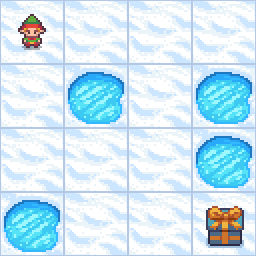

In [5]:
print("PRANAL BORSE - 221A026 ")
env.render()

In [6]:
print("PRANAL BORSE - 221A026 ")
def policy_evaluation(policy, environment, discount_factor=1.0, theta=1e-9, max_iterations=1e9):

    #Initialize the value function for each state to zero
    V = np.zeros(environment.observation_space.n)
    # Number of evaluation iterations
    evaluation_iterations = 1

    for i in range(int(max_iterations)):
        # Initialize a change of value function as zero
        delta = 0

        # Iterate through each state
        for state in range(environment.observation_space.n):
            # Initialize a new value of the current state
            v = 0

            # Try all possible actions which can be taken from this state
            for action, action_probability in enumerate(policy[state]):
                # Check how good the next state will be
                for state_probability, next_state, reward, terminated in environment.unwrapped.P[state][action]:
                    # Calculate the expected value
                    v += action_probability * state_probability * (reward + discount_factor * V[next_state])

            # Calculate the absolute change of value function
            delta = max(delta, np.abs(V[state] - v))
            # Update value function
            V[state] = v

        evaluation_iterations += 1

        #Terminate if value change is significant
        if delta < theta:
            print(f'Policy evaluated in {evaluation_iterations} iterations.')
            return V

    print(f'Maximum iterations reached. Policy evaluation terminated after{max_iterations} iterations.')
    return V

PRANAL BORSE - 221A026 


In [7]:
print("PRANAL BORSE - 221A026 ")
def one_step_lookahead(environment, state, V, discount_factor):
    action_values = np.zeros(environment.action_space.n)
    for action in range(environment.action_space.n):
        for probability, next_state, reward, terminated in environment.unwrapped.P[state][action]:
            action_values[action] += probability * (reward + discount_factor * V[next_state])
    return action_values

PRANAL BORSE - 221A026 


In [8]:
print("PRANAL BORSE - 221A026 ")
def policy_iteration(environment, discount_factor=1.0, max_iterations=1e9):
    # Start with a random policy
    # num states x num actions / num actions
    policy = np.ones([environment.observation_space.n, environment.action_space.n]) / environment.action_space.n
    # Initialize counter of evaluated policies
    evaluated_policies = 1
    # Repeat until convergence or critical number of iterations reached
    for i in range(int(max_iterations)):
        stable_policy = True
        # Evaluate current policy
        V = policy_evaluation(policy, environment, discount_factor=discount_factor)

        # Policy Improvement Step
        for state in range(environment.observation_space.n):
            # Choose the best action in a current state under current policy
            current_action = np.argmax(policy[state])
            # Look one step ahead and evaluate if current action is optimal
            action_value = one_step_lookahead(environment, state, V, discount_factor)
            # Select a better action
            best_action = np.argmax(action_value)

            # If action changed for this state
            if current_action != best_action:
                stable_policy = False
                # Greedy policy update
                policy[state] = np.eye(environment.action_space.n)[best_action]

        # If the policy has changed in this iteration, increment the counter for evaluated policies.
        # This effectively counts how many times the policy was improved and then re-evaluated.
        if not stable_policy:
            evaluated_policies += 1

        # If the algorithm converged and policy is not changing anymore, then return final policy and value function
        if stable_policy:
            print(f'Evaluated {evaluated_policies} policies.')
            return policy, V

    # If maximum iterations reached without convergence
    print(f'Maximum iterations reached. Policy iteration terminated after {max_iterations} iterations.')
    return policy, V

PRANAL BORSE - 221A026 


In [9]:
print("PRANAL BORSE - 221A026 ")
def value_iteration(environment, discount_factor=1.0, theta=1e-9, max_iterations=1e9):
    # Initialize state-value function with zeros for each environment state
    V = np.zeros(environment.observation_space.n)
    for i in range(int(max_iterations)):
        # Early stopping condition
        delta = 0
        # Update each state
        for state in range(environment.observation_space.n):
            # Do a one-step lookahead to calculate state-action values
            action_value = one_step_lookahead(environment, state, V, discount_factor)
            # Select best action to perform based on the highest state-action value
            best_action_value = np.max(action_value)
            # Calculate change in value
            delta = max(delta, np.abs(V[state] - best_action_value))
            # Update the value function for current state
            V[state] = best_action_value
            # Check if we can stop
        if delta < theta:
            print(f'Value-iteration converged at iteration#{i}.')
            break
    # Create a deterministic policy using the optimal value function
    policy = np.zeros([environment.observation_space.n, environment.action_space.n])
    for state in range(environment.observation_space.n):
        # One step lookahead to find the best action for this state
        action_value = one_step_lookahead(environment, state, V, discount_factor)
        # Select best action based on the highest state-action value
        best_action = np.argmax(action_value)
        # Update the policy to perform a better action at a current state
        policy[state, best_action] = 1.0
    return policy, V

PRANAL BORSE - 221A026 


In [10]:
print("PRANAL BORSE - 221A026 ")
policy, V = policy_iteration(env)
print(policy)

PRANAL BORSE - 221A026 
Policy evaluated in 66 iterations.
Policy evaluated in 170 iterations.
Policy evaluated in 428 iterations.
Evaluated 3 policies.
[[0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   1.   0.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]]


In [11]:
print("PRANAL BORSE - 221A026 ")
import gymnasium as gym
import numpy as np

PRANAL BORSE - 221A026 


In [12]:
print("PRANAL BORSE - 221A026 ")
def play_episodes(environment, n_episodes, policy):
        wins = 0
        total_reward = 0
        for episode in range(n_episodes):
                 terminated = False
                 # For gymnasium, reset() returns (observation, info)
                 state, _ = environment.reset()
                 while not terminated:
                         # Select best action to perform in a current state
                         action = np.argmax(policy[state])
                         # For gymnasium, step() returns (observation, reward, terminated, truncated, info)
                         next_state, reward, terminated, truncated, info = environment.step(action)
                         # Summarize total reward
                         total_reward += reward
                         # Update current state
                         state = next_state
                         # Calculate number of wins over episodes
                         if terminated and reward == 1.0:
                                  wins += 1
        average_reward = total_reward / n_episodes
        return wins, total_reward, average_reward

# List of episode counts to run
n_episodes_list = [1000, 10000]

# Functions to find best policy
solvers = [('Policy Iteration', policy_iteration),
           ('Value Iteration', value_iteration)]

for n_episodes in n_episodes_list:
    print(f"--- Running experiments for {n_episodes} episodes ---")
    for iteration_name, iteration_func in solvers:
            # Load a Frozen Lake environment
            # The new step API is default in gymnasium, so `new_step_api=True` is not needed.
            environment = gym.make('FrozenLake-v1')
            # Search for an optimal policy using policy iteration
            # The policy iteration and value iteration functions expect the environment object directly.
            policy, V = iteration_func(environment)
            # Apply best policy to the real environment
            wins, total_reward, average_reward = play_episodes(environment, n_episodes, policy)
            print(f'{iteration_name} :: number of wins over {n_episodes} episodes = {wins}')
            print(f'{iteration_name} :: average reward over {n_episodes} episodes = {average_reward} \n\n')


PRANAL BORSE - 221A026 
--- Running experiments for 1000 episodes ---
Policy evaluated in 66 iterations.
Policy evaluated in 170 iterations.
Policy evaluated in 428 iterations.
Evaluated 3 policies.
Policy Iteration :: number of wins over 1000 episodes = 819
Policy Iteration :: average reward over 1000 episodes = 0.819 


Value-iteration converged at iteration#523.
Value Iteration :: number of wins over 1000 episodes = 826
Value Iteration :: average reward over 1000 episodes = 0.826 


--- Running experiments for 10000 episodes ---
Policy evaluated in 66 iterations.
Policy evaluated in 170 iterations.
Policy evaluated in 428 iterations.
Evaluated 3 policies.
Policy Iteration :: number of wins over 10000 episodes = 8163
Policy Iteration :: average reward over 10000 episodes = 0.8163 


Value-iteration converged at iteration#523.
Value Iteration :: number of wins over 10000 episodes = 8203
Value Iteration :: average reward over 10000 episodes = 0.8203 




In [13]:
env.reset()
print("PRANAL BORSE - 221A026 ")

PRANAL BORSE - 221A026 


PRANAL BORSE - 221A026 


array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
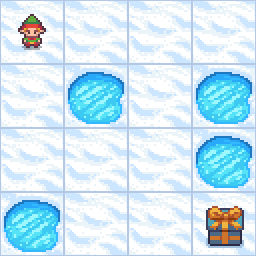

In [14]:
print("PRANAL BORSE - 221A026 ")
env.render()